In [1]:
import sys
sys.path.insert(0, '../lib')

In [2]:
import joblib
import pathlib
import json

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.multitest
import adjustText

import common_data
import common_plots
import pb_utils

In [3]:
%config InlineBackend.figure_format = 'retina'

In [4]:
common_plots.setup_plotting()

In [ ]:
BASE = pathlib.Path('70_degs')

In [6]:
CELL_TYPE_ORDER = [
    'NUPR1+ Macs',
    'MRC1+C1QA+',
    'MRC1+C1QA-',
    'DC2',
    'Classical monocytes-2 IL1B',
    'Classical monocytes-1 CCR2',
    'Non-classical monocytes',
    'Interstitial macrophages',
    'Proliferating NUPR1+ Macs',

    'CD4 T cells',
    'CD8 T cells',
    'gdT cells',
    'Tregs',
    'Proliferating CD4 T cells',
    'Proliferating CD8 T cells',

    'B cells',
    'Plasma cells',
    'Proliferating plasma cells',

    'Ciliated cells',
    'Secretory cells'
]

In [7]:
MAIN_CELL_TYPE_ORDER = [
    'NUPR1+ Macs',
    'MRC1+C1QA+',
    'MRC1+C1QA-',
    'DC2',
    'Classical monocytes-2 IL1B',
    'Classical monocytes-1 CCR2',
    'Interstitial macrophages',
    'Proliferating NUPR1+ Macs',

    'CD4 T cells',
    'CD8 T cells',
    'gdT cells',
    'Tregs',
    'Proliferating CD4 T cells',
    'Proliferating CD8 T cells',
]

# 3. GSEA

1. NPC vs Early SARS-CoV-2
2. alive vs dead early SARS-CoV-2
3. alive vs dead bacteria only
4. alive vs dead pathogen-negative
5. serial baseline

In [8]:
DROP_BOTTOM_BASEMEAN = 0.2
PADJ_CUTOFF = 0.05
class ComparisonInfo:
    def __init__(self, control, condition, genes, genes_to_keep):
        self.control = control
        self.condition = condition
        self.genes_raw = genes
        self.filter_genes(genes_to_keep)

    def filter_genes(self, genes_to_keep):
        filtered_degs = self.genes_raw.loc[self.genes_raw.index.isin(genes_to_keep), :].copy()
        filtered_degs = filtered_degs.loc[filtered_degs.pvalue.notna()].copy()
        basemean = filtered_degs.baseMean.quantile(DROP_BOTTOM_BASEMEAN)
        filtered_degs = filtered_degs.loc[filtered_degs.baseMean.gt(basemean)].copy()
        # recompute FDR correction on the filtered genes:
        filtered_degs['padj'] = statsmodels.stats.multitest.fdrcorrection(
            filtered_degs.pvalue,
            alpha=PADJ_CUTOFF
        )[1]
        # recompute gene status based on new `padj`
        filtered_degs['sign'] = ''
        filtered_degs.loc[
            filtered_degs.padj.lt(PADJ_CUTOFF)
            & filtered_degs.log2FoldChange.gt(0),
            'sign'
        ] = f'Up in {self.condition}'
        filtered_degs.loc[
            filtered_degs.padj.lt(PADJ_CUTOFF)
            & filtered_degs.log2FoldChange.lt(0),
            'sign'
        ] = f'Up in {self.control}'
        self.genes = filtered_degs


class CellTypeInfo:
    def __init__(self, path, task_info, genes_to_keep):
        self.path = path
        self.task_info = task_info
        self.comparisons = []
        self.meta = pd.read_csv(path / 'meta.csv', index_col=0)
        self.name = self.meta.cell_type.values[0]

        self.load_comparisons(genes_to_keep)

    def load_comparisons(self, genes_to_keep):
        for run in self.path.glob('**/degs.csv'):
            self.comparisons.append(
                ComparisonInfo(
                    self.task_info.column_values[0],
                    self.task_info.column_values[1],
                    pd.read_csv(run, index_col=0),
                    genes_to_keep[self.name]
                )
            )

    @property
    def n_comparisons(self):
        return len(self.comparisons)

In [9]:
class TaskData:
    def __init__(self, task, task_info):
        self.task = task
        self.task_info = task_info
        self.info = {}

In [ ]:
data = joblib.load('50c_deg_data.joblib')

In [ ]:
PATHOGEN_BASE = pathlib.Path('../data/05_pseudobulk/50c_degs/')

In [12]:
result = {}
for _, task in data.items():
    gseas = []
    for k, ct_info in task.info.items():
        comp = ct_info.comparisons[0]
        gsea_path = PATHOGEN_BASE / task.task_info.pathname / k / 'gsea.csv'
        if not gsea_path.exists():
            print(f'No GSEA for {k} in {task.task_info.pathname}')
            continue
        gsea = pd.read_csv(gsea_path, index_col=0)
        gsea['cell_type'] = k
        if k == 'Perivascular_macrophages':
            gsea['cell_type'] = 'Interstitial_macrophages'
        gseas.append(gsea)
    result[task.task_info.pathname] = pd.concat(gseas)

No GSEA for pDC in immunocompromised


In [13]:
GSEA_LIST = [
    'HALLMARK_INFLAMMATORY_RESPONSE',
    'HALLMARK_INTERFERON_ALPHA_RESPONSE',
    'HALLMARK_INTERFERON_GAMMA_RESPONSE',
    'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
    'HALLMARK_IL6_JAK_STAT3_SIGNALING',
    'HALLMARK_IL2_STAT5_SIGNALING',
    'HALLMARK_COMPLEMENT',
    'HALLMARK_COAGULATION',
    'HALLMARK_ALLOGRAFT_REJECTION',
    'HALLMARK_PROTEIN_SECRETION',
    'HALLMARK_G2M_CHECKPOINT',
    'HALLMARK_MITOTIC_SPINDLE',
    'HALLMARK_PI3K_AKT_MTOR_SIGNALING',
    'HALLMARK_MTORC1_SIGNALING',
    'HALLMARK_E2F_TARGETS',
    'HALLMARK_APOPTOSIS',

    'HALLMARK_HYPOXIA',
    'HALLMARK_GLYCOLYSIS',
    'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
    'HALLMARK_FATTY_ACID_METABOLISM',
    'HALLMARK_PEROXISOME',
    'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY',
    'HALLMARK_UNFOLDED_PROTEIN_RESPONSE',
    'HALLMARK_XENOBIOTIC_METABOLISM',

    'HALLMARK_ANDROGEN_RESPONSE',
    'HALLMARK_ESTROGEN_RESPONSE_EARLY',
    'HALLMARK_ESTROGEN_RESPONSE_LATE',

    'HALLMARK_DNA_REPAIR',
    'HALLMARK_TGF_BETA_SIGNALING',
    'HALLMARK_ANGIOGENESIS',
    'HALLMARK_NOTCH_SIGNALING'
]

## G+ vs G– comparison

In [14]:
result.keys()

dict_keys(['gram+_vs_gram-', 'pseudomonas_vs_gram-', 'age', 'sex', 'immunocompromised', 'days_on_vent', 'steroid_dose'])

In [15]:
gsea = result['gram+_vs_gram-']
gsea['p-value'] = gsea['NOM p-value'].copy()
idx = gsea['p-value'].eq(0)
min_p_val = gsea['p-value'][~idx].min()
gsea.loc[idx, 'p-value'] = min_p_val * 0.01

print(f'P-values exactly 0: {idx.sum()} in gram+_vs_gram-')

gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
gsea['-log10(padj)'] = -np.log10(gsea.padj)
gsea['-log10(padj)'] *= np.sign(gsea.NES)
gsea_df = gsea.pivot_table(
    index='cell_type',
    columns='Term',
    values='-log10(padj)'
)
gsea_df = gsea_df.loc[:, GSEA_LIST]
gsea_df.index = gsea_df.index.str.replace('_', ' ')

gsea_df_plot = gsea_df.fillna(0).T

P-values exactly 0: 31 in gram+_vs_gram-


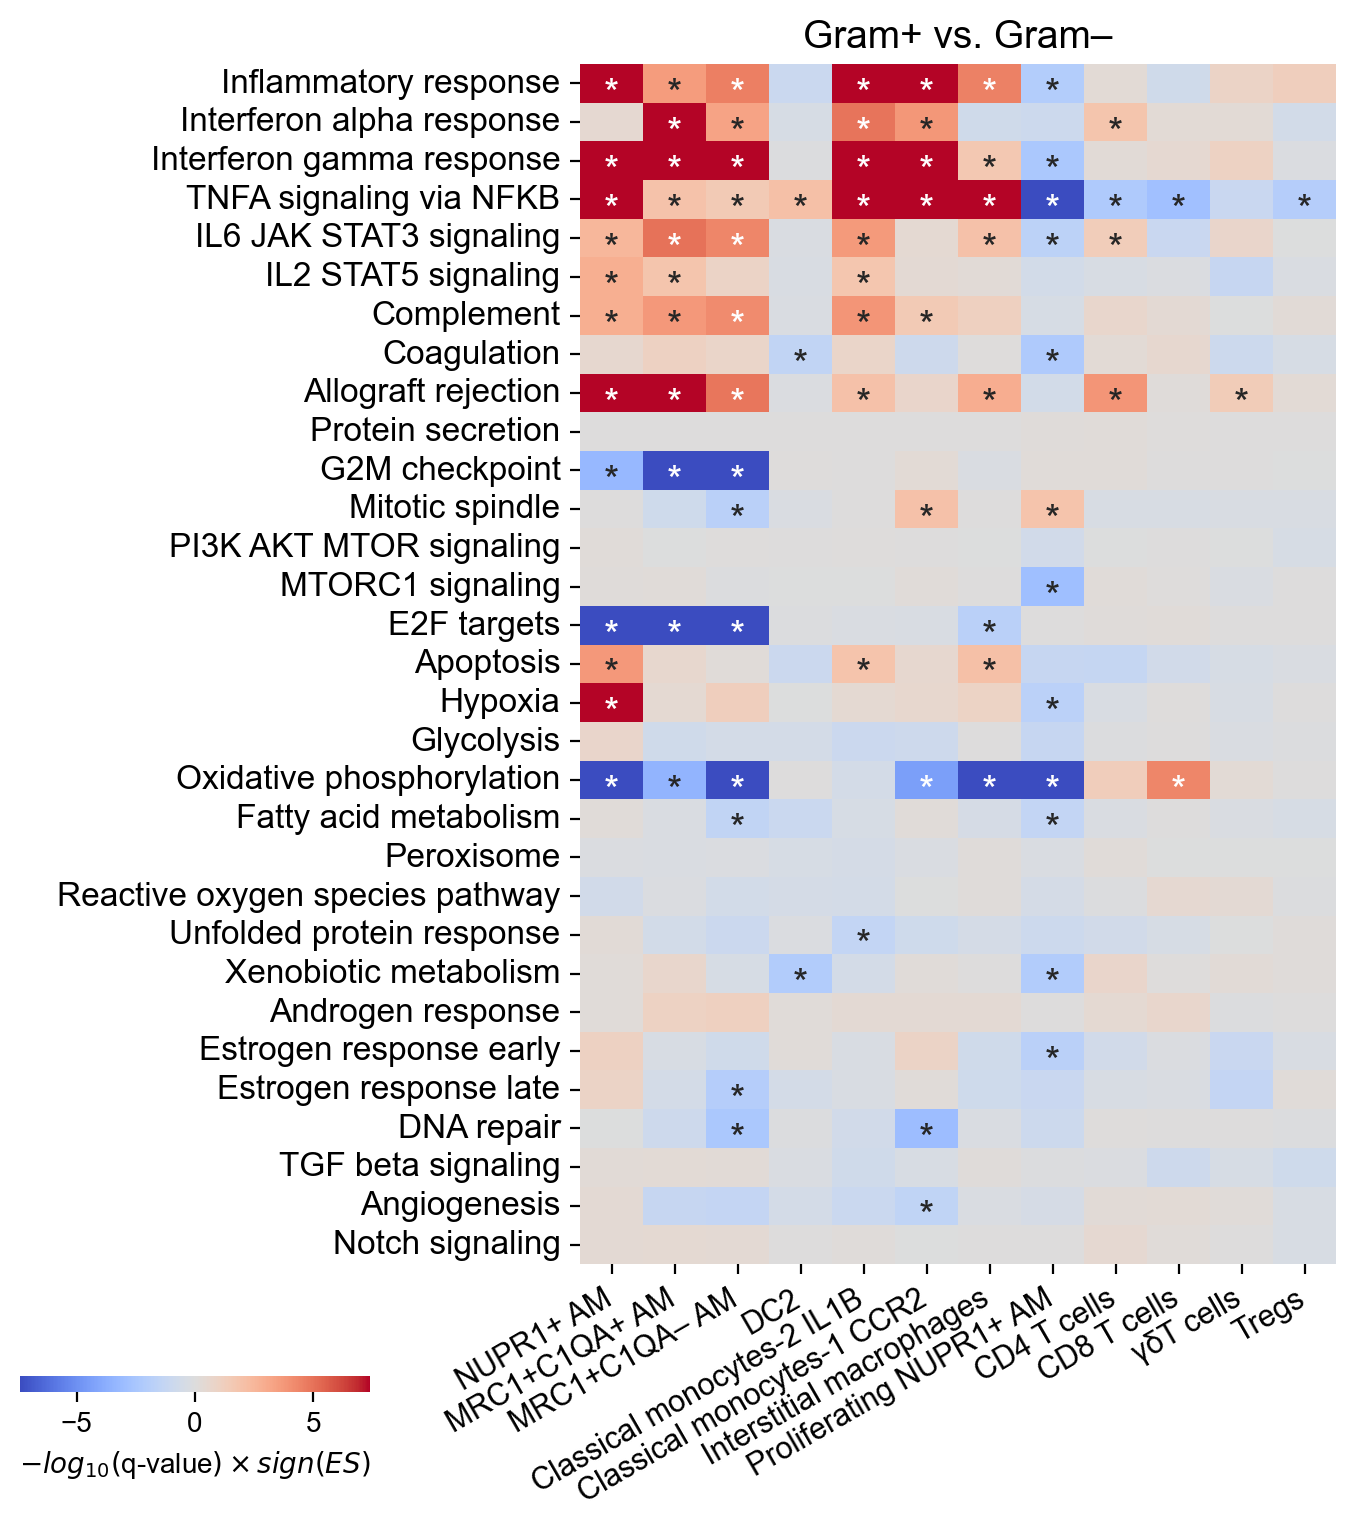

In [ ]:
fig, ax = plt.subplots(constrained_layout=False, figsize=(7, 8))

rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

present_cell_types = pd.Series(MAIN_CELL_TYPE_ORDER)
present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]
gsea_df_plot.columns = pd.Series(gsea_df_plot.columns).replace(common_plots.CELL_TYPES_DISPLAY)

stars = np.empty_like(gsea_df_plot, dtype=str)
stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

cax = fig.add_axes((0.05, 0.12, 0.25, 0.01))

cg = sns.heatmap(
    gsea_df_plot,
    cbar_ax=cax,
    xticklabels=gsea_df_plot.columns,
    yticklabels=[pb_utils.process_hallmark_name(x) for x in rownames],
    cmap='coolwarm',
    annot=stars,
    fmt='',
    annot_kws=dict(
        va='center_baseline',
        fontsize=14
    ),
    cbar_kws=dict(
        label='$-log_{10}($q-value$) \\times sign(ES)$',
        orientation='horizontal'
    ),
    ax=ax,
    center=0
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontsize=11,
    rotation=30,
    ha='right'
)
# ax.set_title(ORDER[1 + i], fontsize=12)
trans = mpl.transforms.Affine2D().translate(5, 0)
for t in ax.get_xticklabels():
    t.set_transform(t.get_transform() + trans)
for t in ax.texts:
    if t.get_text() == '*':
        p = t.get_position()
        t.set_position((p[0], p[1] + 0.2))

ax.tick_params(axis='y', labelsize=12)
ax.set_title('Gram+ vs. Gram–', fontsize=14)

fig.subplots_adjust(left=0.45, bottom=0.2, top=0.95, right=0.99)
fig.savefig('00_plots/70b_gsea_g+_vs_g-.pdf')

## Age comparison

In [17]:
gsea = result['age']
gsea['p-value'] = gsea['NOM p-value'].copy()
idx = gsea['p-value'].eq(0)
min_p_val = gsea['p-value'][~idx].min()
gsea.loc[idx, 'p-value'] = min_p_val * 0.01

print(f'P-values exactly 0: {idx.sum()} in age')

gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
gsea['-log10(padj)'] = -np.log10(gsea.padj)
gsea['-log10(padj)'] *= np.sign(gsea.NES)
gsea_df = gsea.pivot_table(
    index='cell_type',
    columns='Term',
    values='-log10(padj)'
)
gsea_df = gsea_df.loc[:, GSEA_LIST]
gsea_df.index = gsea_df.index.str.replace('_', ' ')

gsea_df_plot = gsea_df.fillna(0).T

P-values exactly 0: 49 in age


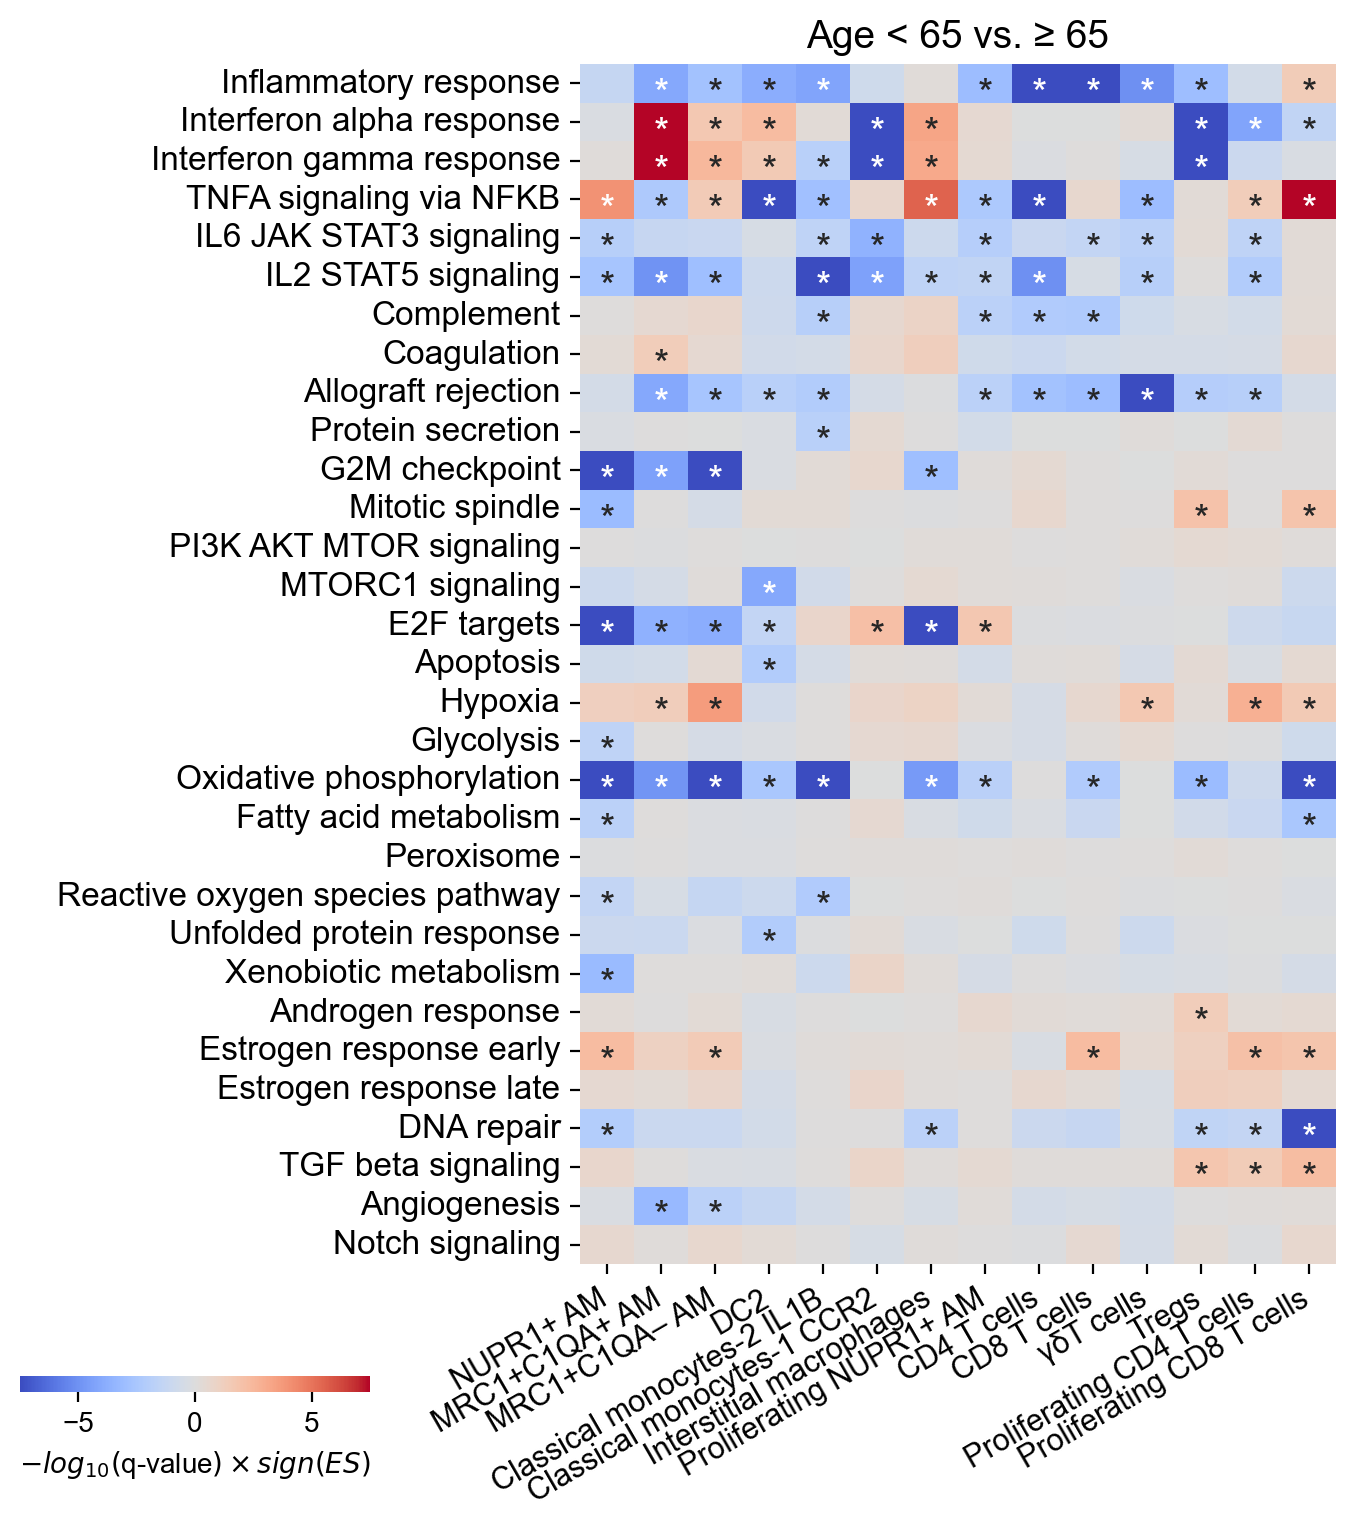

In [ ]:
fig, ax = plt.subplots(constrained_layout=False, figsize=(7, 8))

rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

present_cell_types = pd.Series(MAIN_CELL_TYPE_ORDER)
present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]
gsea_df_plot.columns = pd.Series(gsea_df_plot.columns).replace(common_plots.CELL_TYPES_DISPLAY)

stars = np.empty_like(gsea_df_plot, dtype=str)
stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

cax = fig.add_axes((0.05, 0.12, 0.25, 0.01))

cg = sns.heatmap(
    gsea_df_plot,
    cbar_ax=cax,
    xticklabels=gsea_df_plot.columns,
    yticklabels=[pb_utils.process_hallmark_name(x) for x in rownames],
    cmap='coolwarm',
    annot=stars,
    fmt='',
    annot_kws=dict(
        va='center_baseline',
        fontsize=14
    ),
    cbar_kws=dict(
        label='$-log_{10}($q-value$) \\times sign(ES)$',
        orientation='horizontal'
    ),
    ax=ax,
    center=0
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontsize=11,
    rotation=30,
    ha='right'
)
# ax.set_title(ORDER[1 + i], fontsize=12)
trans = mpl.transforms.Affine2D().translate(5, 0)
for t in ax.get_xticklabels():
    t.set_transform(t.get_transform() + trans)
for t in ax.texts:
    if t.get_text() == '*':
        p = t.get_position()
        t.set_position((p[0], p[1] + 0.2))

ax.tick_params(axis='y', labelsize=12)
ax.set_title('Age < 65 vs. ≥ 65', fontsize=14)

fig.subplots_adjust(left=0.45, bottom=0.2, top=0.95, right=0.99)
fig.savefig('00_plots/70b_gsea_age.pdf')

## Immunocompromised comparison

In [19]:
result.keys()

dict_keys(['gram+_vs_gram-', 'pseudomonas_vs_gram-', 'age', 'sex', 'immunocompromised', 'days_on_vent', 'steroid_dose'])

In [20]:
gsea = result['immunocompromised']
gsea['p-value'] = gsea['NOM p-value'].copy()
idx = gsea['p-value'].eq(0)
min_p_val = gsea['p-value'][~idx].min()
gsea.loc[idx, 'p-value'] = min_p_val * 0.01

print(f'P-values exactly 0: {idx.sum()} in immunocompromised')

gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
gsea['-log10(padj)'] = -np.log10(gsea.padj)
gsea['-log10(padj)'] *= np.sign(gsea.NES)
gsea_df = gsea.pivot_table(
    index='cell_type',
    columns='Term',
    values='-log10(padj)'
)
gsea_df = gsea_df.loc[:, GSEA_LIST]
gsea_df.index = gsea_df.index.str.replace('_', ' ')

gsea_df_plot = gsea_df.fillna(0).T

P-values exactly 0: 49 in immunocompromised


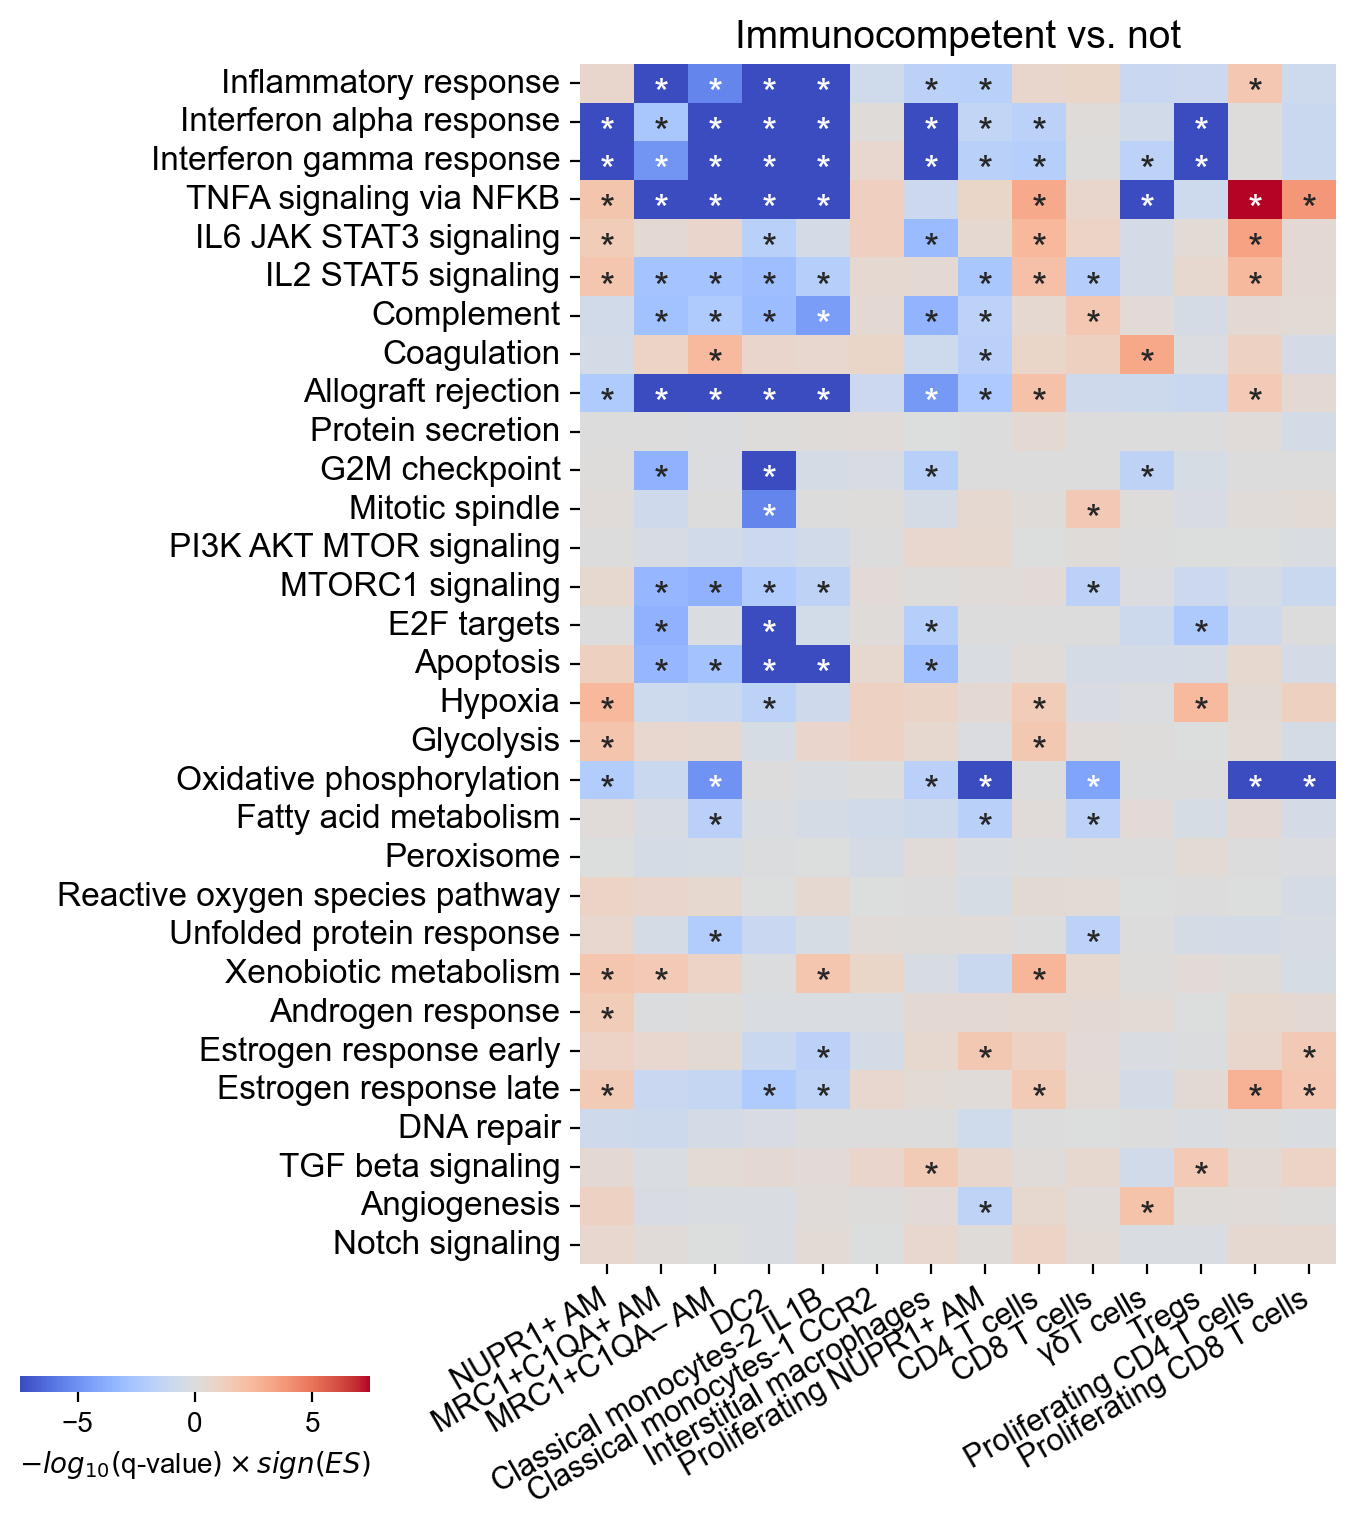

In [ ]:
fig, ax = plt.subplots(constrained_layout=False, figsize=(7, 8))

rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

present_cell_types = pd.Series(MAIN_CELL_TYPE_ORDER)
present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]
gsea_df_plot.columns = pd.Series(gsea_df_plot.columns).replace(common_plots.CELL_TYPES_DISPLAY)

stars = np.empty_like(gsea_df_plot, dtype=str)
stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

cax = fig.add_axes((0.05, 0.12, 0.25, 0.01))

cg = sns.heatmap(
    gsea_df_plot,
    cbar_ax=cax,
    xticklabels=gsea_df_plot.columns,
    yticklabels=[pb_utils.process_hallmark_name(x) for x in rownames],
    cmap='coolwarm',
    annot=stars,
    fmt='',
    annot_kws=dict(
        va='center_baseline',
        fontsize=14
    ),
    cbar_kws=dict(
        label='$-log_{10}($q-value$) \\times sign(ES)$',
        orientation='horizontal'
    ),
    ax=ax,
    center=0
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontsize=11,
    rotation=30,
    ha='right'
)
# ax.set_title(ORDER[1 + i], fontsize=12)
trans = mpl.transforms.Affine2D().translate(5, 0)
for t in ax.get_xticklabels():
    t.set_transform(t.get_transform() + trans)
for t in ax.texts:
    if t.get_text() == '*':
        p = t.get_position()
        t.set_position((p[0], p[1] + 0.2))

ax.tick_params(axis='y', labelsize=12)
ax.set_title('Immunocompetent vs. not', fontsize=14)

fig.subplots_adjust(left=0.45, bottom=0.2, top=0.95, right=0.99)
fig.savefig('00_plots/70b_gsea_immunocompromised.pdf')

## Steroid

In [22]:
result.keys()

dict_keys(['gram+_vs_gram-', 'pseudomonas_vs_gram-', 'age', 'sex', 'immunocompromised', 'days_on_vent', 'steroid_dose'])

In [23]:
gsea = result['steroid_dose']
gsea['p-value'] = gsea['NOM p-value'].copy()
idx = gsea['p-value'].eq(0)
min_p_val = gsea['p-value'][~idx].min()
gsea.loc[idx, 'p-value'] = min_p_val * 0.01

print(f'P-values exactly 0: {idx.sum()} in steroid_dose')

gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
gsea['-log10(padj)'] = -np.log10(gsea.padj)
gsea['-log10(padj)'] *= np.sign(gsea.NES)
gsea_df = gsea.pivot_table(
    index='cell_type',
    columns='Term',
    values='-log10(padj)'
)
gsea_df = gsea_df.loc[:, GSEA_LIST]
gsea_df.index = gsea_df.index.str.replace('_', ' ')

gsea_df_plot = gsea_df.fillna(0).T

P-values exactly 0: 72 in steroid_dose


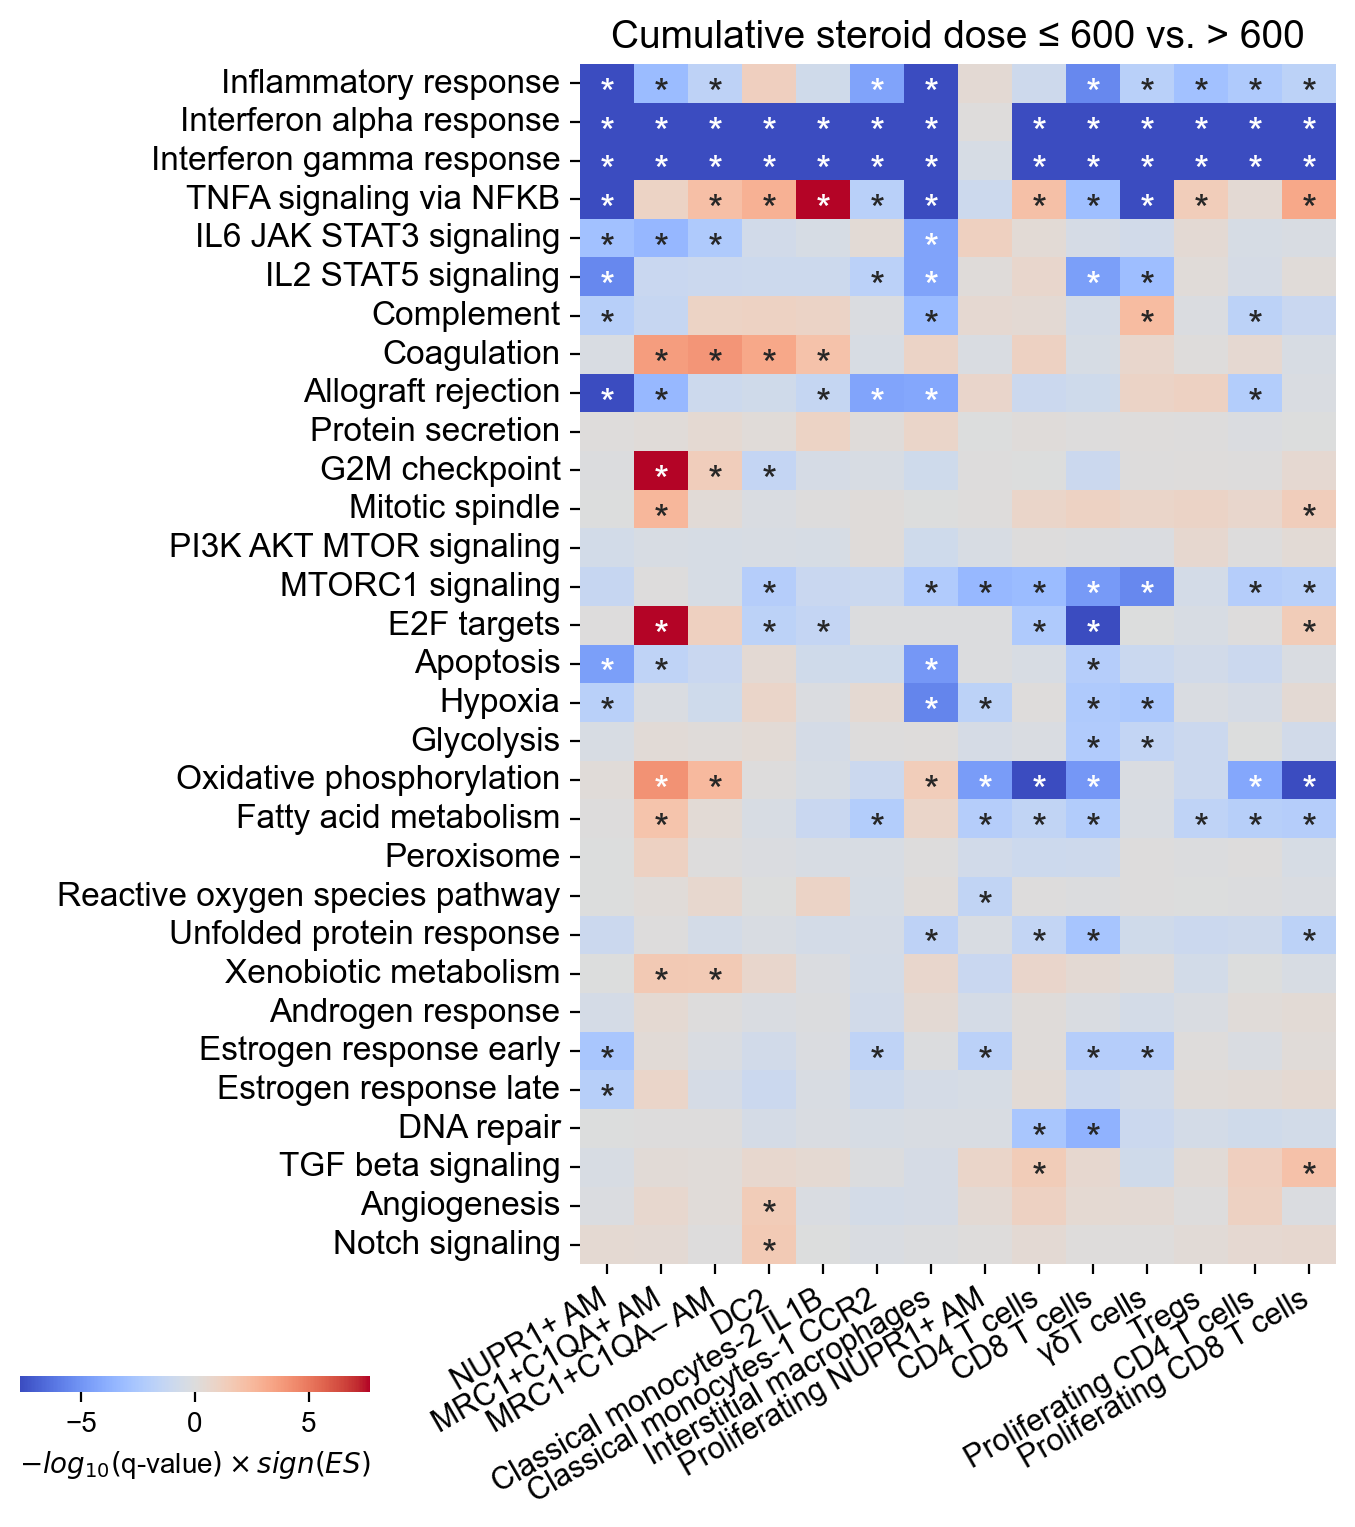

In [ ]:
fig, ax = plt.subplots(constrained_layout=False, figsize=(7, 8))

rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

present_cell_types = pd.Series(MAIN_CELL_TYPE_ORDER)
present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]
gsea_df_plot.columns = pd.Series(gsea_df_plot.columns).replace(common_plots.CELL_TYPES_DISPLAY)

stars = np.empty_like(gsea_df_plot, dtype=str)
stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

cax = fig.add_axes((0.05, 0.12, 0.25, 0.01))

cg = sns.heatmap(
    gsea_df_plot,
    cbar_ax=cax,
    xticklabels=gsea_df_plot.columns,
    yticklabels=[pb_utils.process_hallmark_name(x) for x in rownames],
    cmap='coolwarm',
    annot=stars,
    fmt='',
    annot_kws=dict(
        va='center_baseline',
        fontsize=14
    ),
    cbar_kws=dict(
        label='$-log_{10}($q-value$) \\times sign(ES)$',
        orientation='horizontal'
    ),
    ax=ax,
    center=0
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontsize=11,
    rotation=30,
    ha='right'
)
# ax.set_title(ORDER[1 + i], fontsize=12)
trans = mpl.transforms.Affine2D().translate(5, 0)
for t in ax.get_xticklabels():
    t.set_transform(t.get_transform() + trans)
for t in ax.texts:
    if t.get_text() == '*':
        p = t.get_position()
        t.set_position((p[0], p[1] + 0.2))

ax.tick_params(axis='y', labelsize=12)
ax.set_title('Cumulative steroid dose ≤ 600 vs. > 600', fontsize=14)

fig.subplots_adjust(left=0.45, bottom=0.2, top=0.95, right=0.99)
fig.savefig('00_plots/70b_gsea_steroid_dose.pdf')

# 5. Viral vs Bacterial MA plots

To visualize genes in MA, we will only highlight secretome, accessible from https://www.proteinatlas.org/humanproteome/subcellular/secreted+proteins
and downloadable from https://www.proteinatlas.org/search/protein_class%3APredicted+secreted+proteins

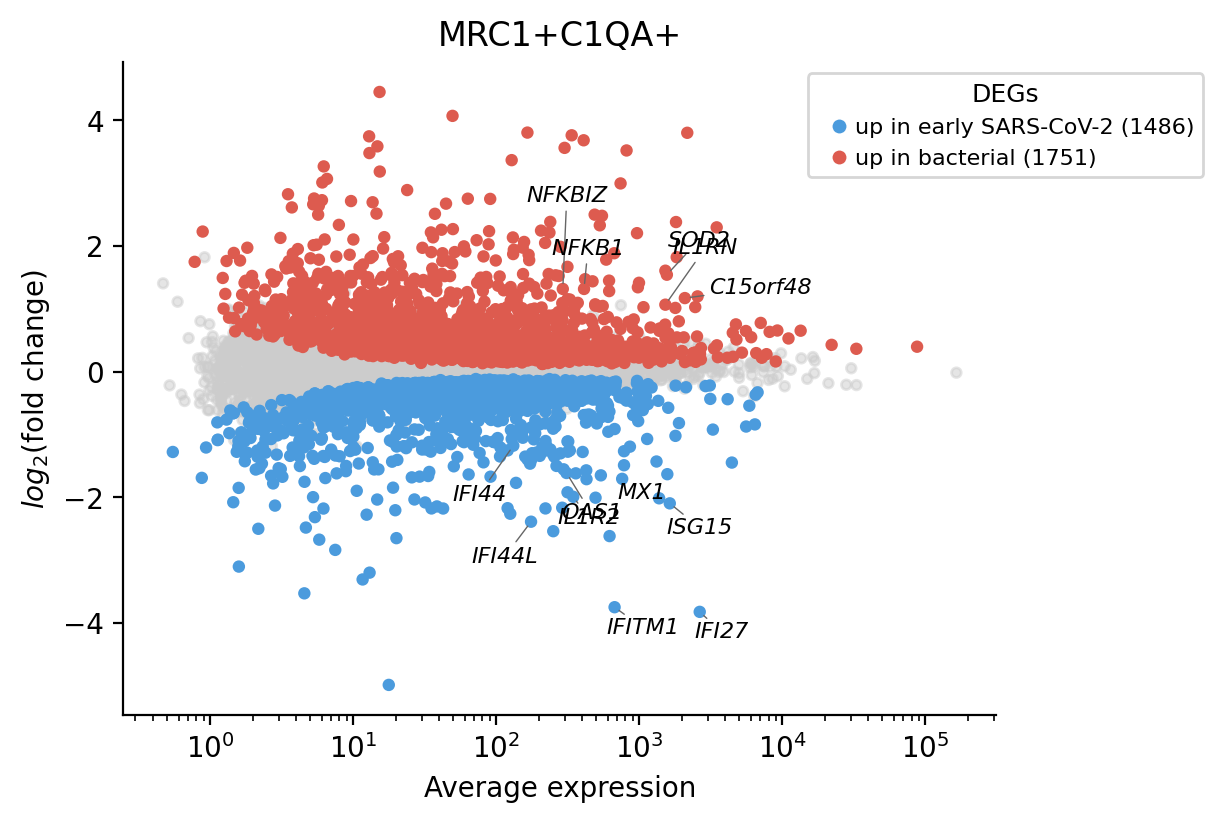

In [ ]:
fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(6, 4))
all_texts = []
cell_type = 'MRC1+C1QA+'

degs = data['Early SARS-CoV-2_vs_Bacteria'].info[cell_type].comparisons[0].genes.copy()
# degs = degs.loc[degs.index.isin(secretome.Gene)]

degs['color'] = '#cccccc'
degs['order'] = 0
degs['alpha'] = 0.5
control_idx = degs.padj.lt(0.05) & degs.log2FoldChange.lt(0)
condition_idx = degs.padj.lt(0.05) & degs.log2FoldChange.gt(0)
degs.loc[control_idx, 'color'] = '#4b9bdd'
degs.loc[control_idx, 'order'] = 1
degs.loc[condition_idx, 'color'] = '#dd5b4f'
degs.loc[condition_idx, 'order'] = 2
degs.loc[control_idx | condition_idx, 'alpha'] = 1
degs = degs.sort_values('order')
ax.scatter(degs.baseMean, degs.log2FoldChange, c=degs.color, s=12, alpha=degs.alpha)

ax.set_xscale('log')
ax.set_title(cell_type.replace('_', ' '))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelbottom=True)
ax.set_ylabel('$log_2($fold change$)$')
ax.set_xlabel('Average expression')
legend = []
legend.append(mpl.lines.Line2D(
    [0], [0],
    label=f'up in early SARS-CoV-2 ({control_idx.sum()})',
    color='#ffffffff',
    markerfacecolor='#4b9bdd',
    marker='o',
    markersize=6
))
legend.append(mpl.lines.Line2D(
    [0], [0],
    label=f'up in bacterial ({condition_idx.sum()})',
    color='#ffffffff',
    markerfacecolor='#dd5b4f',
    marker='o',
    markersize=6
))
# legend.append(mpl.lines.Line2D(
#     [0], [0],
#     label=f'not significant ({degs.shape[0] - control_idx.sum() - condition_idx.sum()})',
#     color='#ffffffff',
#     markerfacecolor='#cccccc',
#     marker='o',
#     markersize=6
# ))
ax.legend(
    handles=legend,
    fontsize=8,
    frameon=True,
    handletextpad=-0.3,
    loc='upper right',
    bbox_to_anchor=(1.25, 1.0),
    title='DEGs',
    title_fontsize=9
)
texts = []
for gene, r in degs.loc[['MX1', 'IFI27', 'IFITM1', 'IFI44L', 'ISG15', 'IL1R2', 'IFI44', 'OAS1']].iterrows():
    if r.log2FoldChange > 0:
        break
    texts.append(
        ax.text(r.baseMean, r.log2FoldChange, gene, ha='center', va='center', fontstyle='italic', fontsize=8)
    )
for gene, r in degs.loc[['SOD2', 'NFKB1', 'NFKBIZ', 'C15orf48', 'IL1RN']].iterrows():
    if r.log2FoldChange < 0:
        continue
    texts.append(
        ax.text(r.baseMean, r.log2FoldChange, gene, ha='center', va='center', fontstyle='italic', fontsize=8)
    )
adjustText.adjust_text(
    texts,
    objects=ax.collections[0],
    arrowprops=dict(arrowstyle="-", color='#666666', lw=0.5),
    force_static=(0.1, 0.4),
    expand=(1.1, 1.4),
    iter_lim=10,
    ax=ax
)
ax.collections[0].set_rasterized(True)

fig.savefig('00_plots/70b_ma_mrc1+c1qa+_viral_vs_bac.pdf', dpi=300)

# 6. Alive vs Dead GSEA

In [ ]:
data = joblib.load('20c_deg_data.joblib')

In [ ]:
A_VS_D_BASE = pathlib.Path('../data/05_pseudobulk/20c_degs')

In [35]:
result = {}
for _, task in data.items():
    gseas = []
    for k, ct_info in task.info.items():
        comp = ct_info.comparisons[0]
        gsea_path = A_VS_D_BASE / task.task_info.pathname / k / 'gsea.csv'
        if not gsea_path.exists():
            print(f'No GSEA for {k} in {task.task_info.pathname}')
            continue
        gsea = pd.read_csv(gsea_path, index_col=0)
        gsea['cell_type'] = k
        gseas.append(gsea)
    result[task.task_info.pathname] = pd.concat(gseas)

No GSEA for Proliferating_NUPR1+_Macs in alive_vs_dead


In [36]:
gsea = result['alive_vs_dead_viral']
gsea['p-value'] = gsea['NOM p-value'].copy()
idx = gsea['p-value'].eq(0)
min_p_val = gsea['p-value'][~idx].min()
gsea.loc[idx, 'p-value'] = min_p_val * 0.01

print(f'P-values exactly 0: {idx.sum()} in alive_vs_dead')

gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
gsea['-log10(padj)'] = -np.log10(gsea.padj)
gsea['-log10(padj)'] *= np.sign(gsea.NES)
gsea_df = gsea.pivot_table(
    index='cell_type',
    columns='Term',
    values='-log10(padj)'
)
gsea_df = gsea_df.loc[:, GSEA_LIST]
gsea_df.index = gsea_df.index.str.replace('_', ' ')

gsea_df_plot = gsea_df.fillna(0).T

P-values exactly 0: 36 in alive_vs_dead


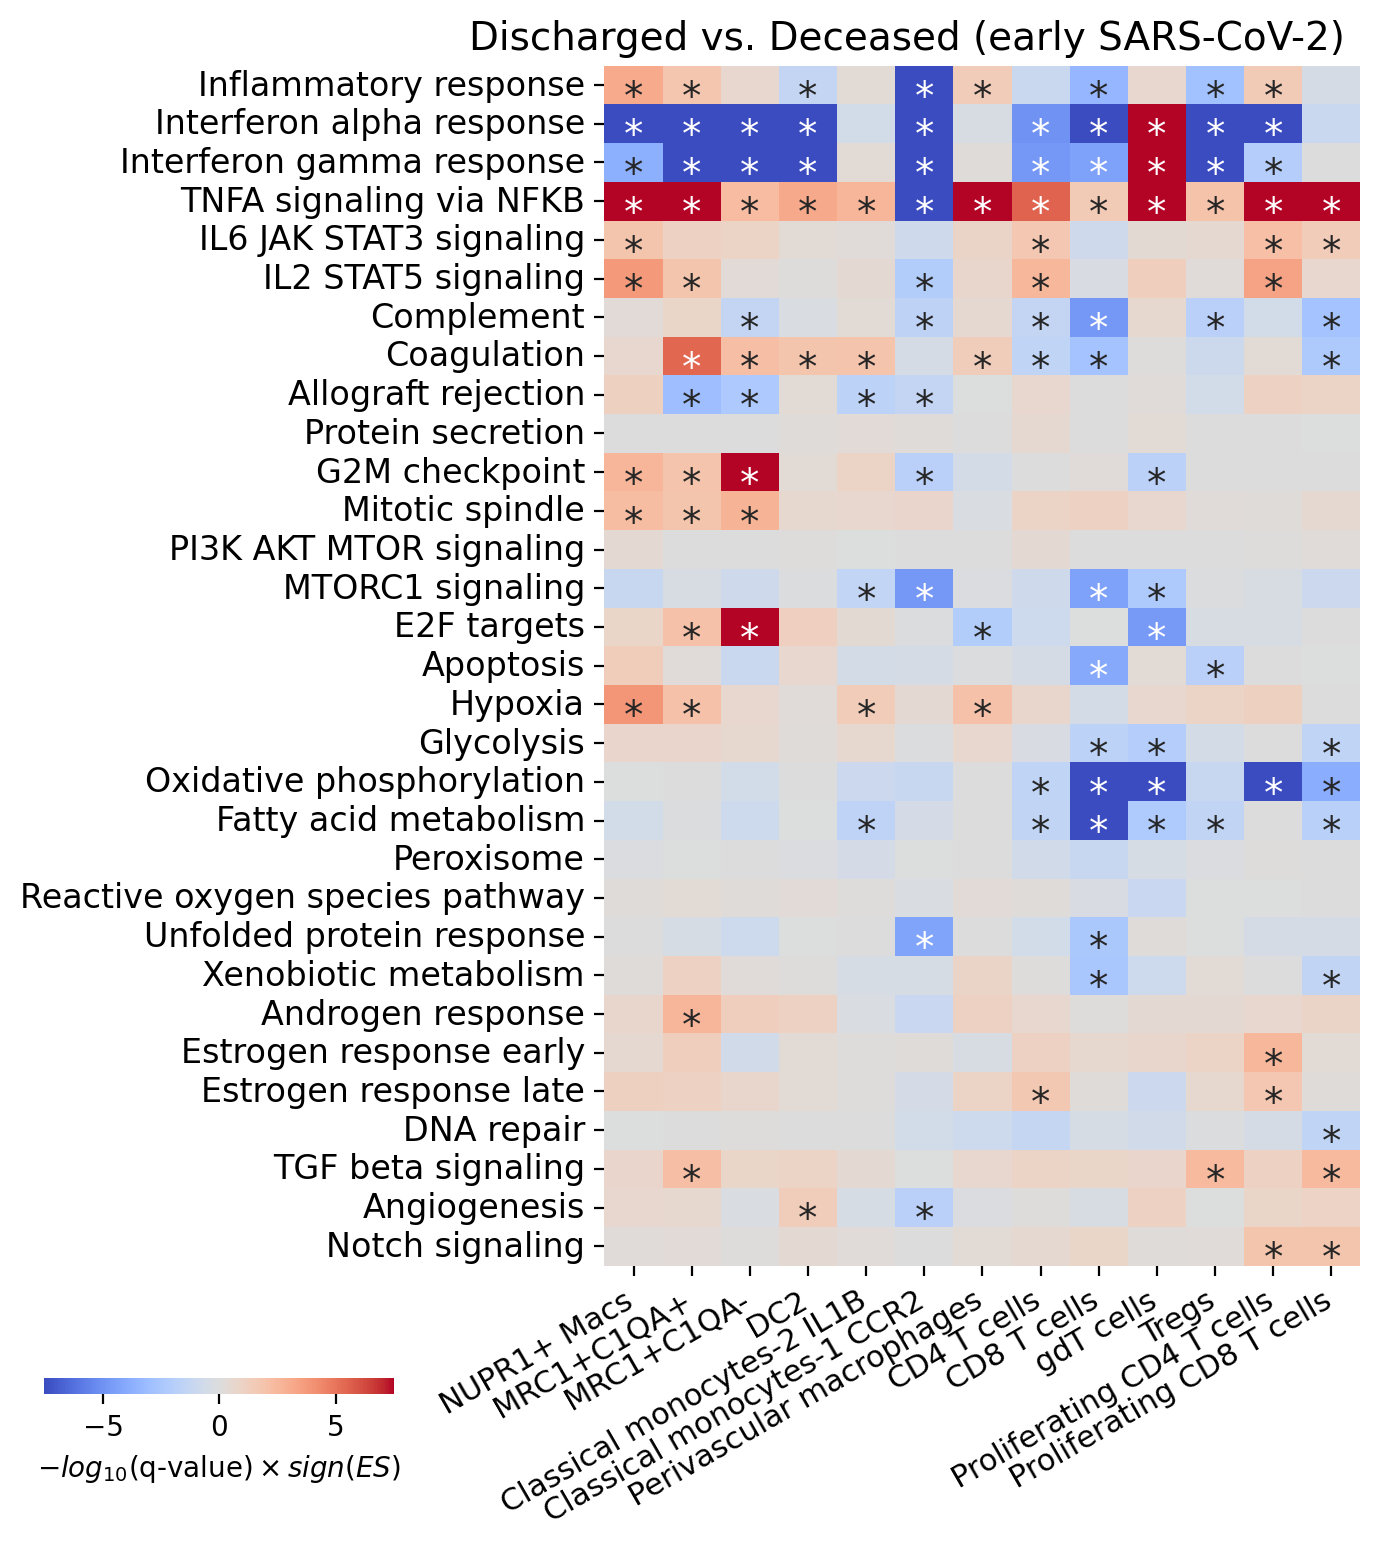

In [ ]:
fig, ax = plt.subplots(constrained_layout=False, figsize=(7, 8))

rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

present_cell_types = pd.Series(MAIN_CELL_TYPE_ORDER)
present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]

stars = np.empty_like(gsea_df_plot, dtype=str)
stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

cax = fig.add_axes((0.05, 0.12, 0.25, 0.01))

cg = sns.heatmap(
    gsea_df_plot,
    cbar_ax=cax,
    xticklabels=gsea_df_plot.columns,
    yticklabels=[pb_utils.process_hallmark_name(x) for x in rownames],
    cmap='coolwarm',
    annot=stars,
    fmt='',
    annot_kws=dict(
        va='center_baseline',
        fontsize=14
    ),
    cbar_kws=dict(
        label='$-log_{10}($q-value$) \\times sign(ES)$',
        orientation='horizontal'
    ),
    ax=ax,
    center=0
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontsize=11,
    rotation=30,
    ha='right'
)
# ax.set_title(ORDER[1 + i], fontsize=12)
trans = mpl.transforms.Affine2D().translate(5, 0)
for t in ax.get_xticklabels():
    t.set_transform(t.get_transform() + trans)
for t in ax.texts:
    if t.get_text() == '*':
        p = t.get_position()
        t.set_position((p[0], p[1] + 0.2))

ax.tick_params(axis='y', labelsize=12, left=True)
ax.tick_params(axis='x', bottom=True)
ax.set_title('Discharged vs. Deceased (early SARS-CoV-2)', fontsize=14, x=0.4)

fig.subplots_adjust(left=0.45, bottom=0.2, top=0.95, right=0.99)
fig.savefig('00_plots/70b_gsea_alive_vs_dead_viral.pdf')

In [39]:
gsea = result['alive_vs_dead_bacterial']
gsea['p-value'] = gsea['NOM p-value'].copy()
idx = gsea['p-value'].eq(0)
min_p_val = gsea['p-value'][~idx].min()
gsea.loc[idx, 'p-value'] = min_p_val * 0.01

print(f'P-values exactly 0: {idx.sum()} in alive_vs_dead')

gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
gsea['-log10(padj)'] = -np.log10(gsea.padj)
gsea['-log10(padj)'] *= np.sign(gsea.NES)
gsea_df = gsea.pivot_table(
    index='cell_type',
    columns='Term',
    values='-log10(padj)'
)
gsea_df = gsea_df.loc[:, GSEA_LIST]
gsea_df.index = gsea_df.index.str.replace('_', ' ')

gsea_df_plot = gsea_df.fillna(0).T

P-values exactly 0: 24 in alive_vs_dead


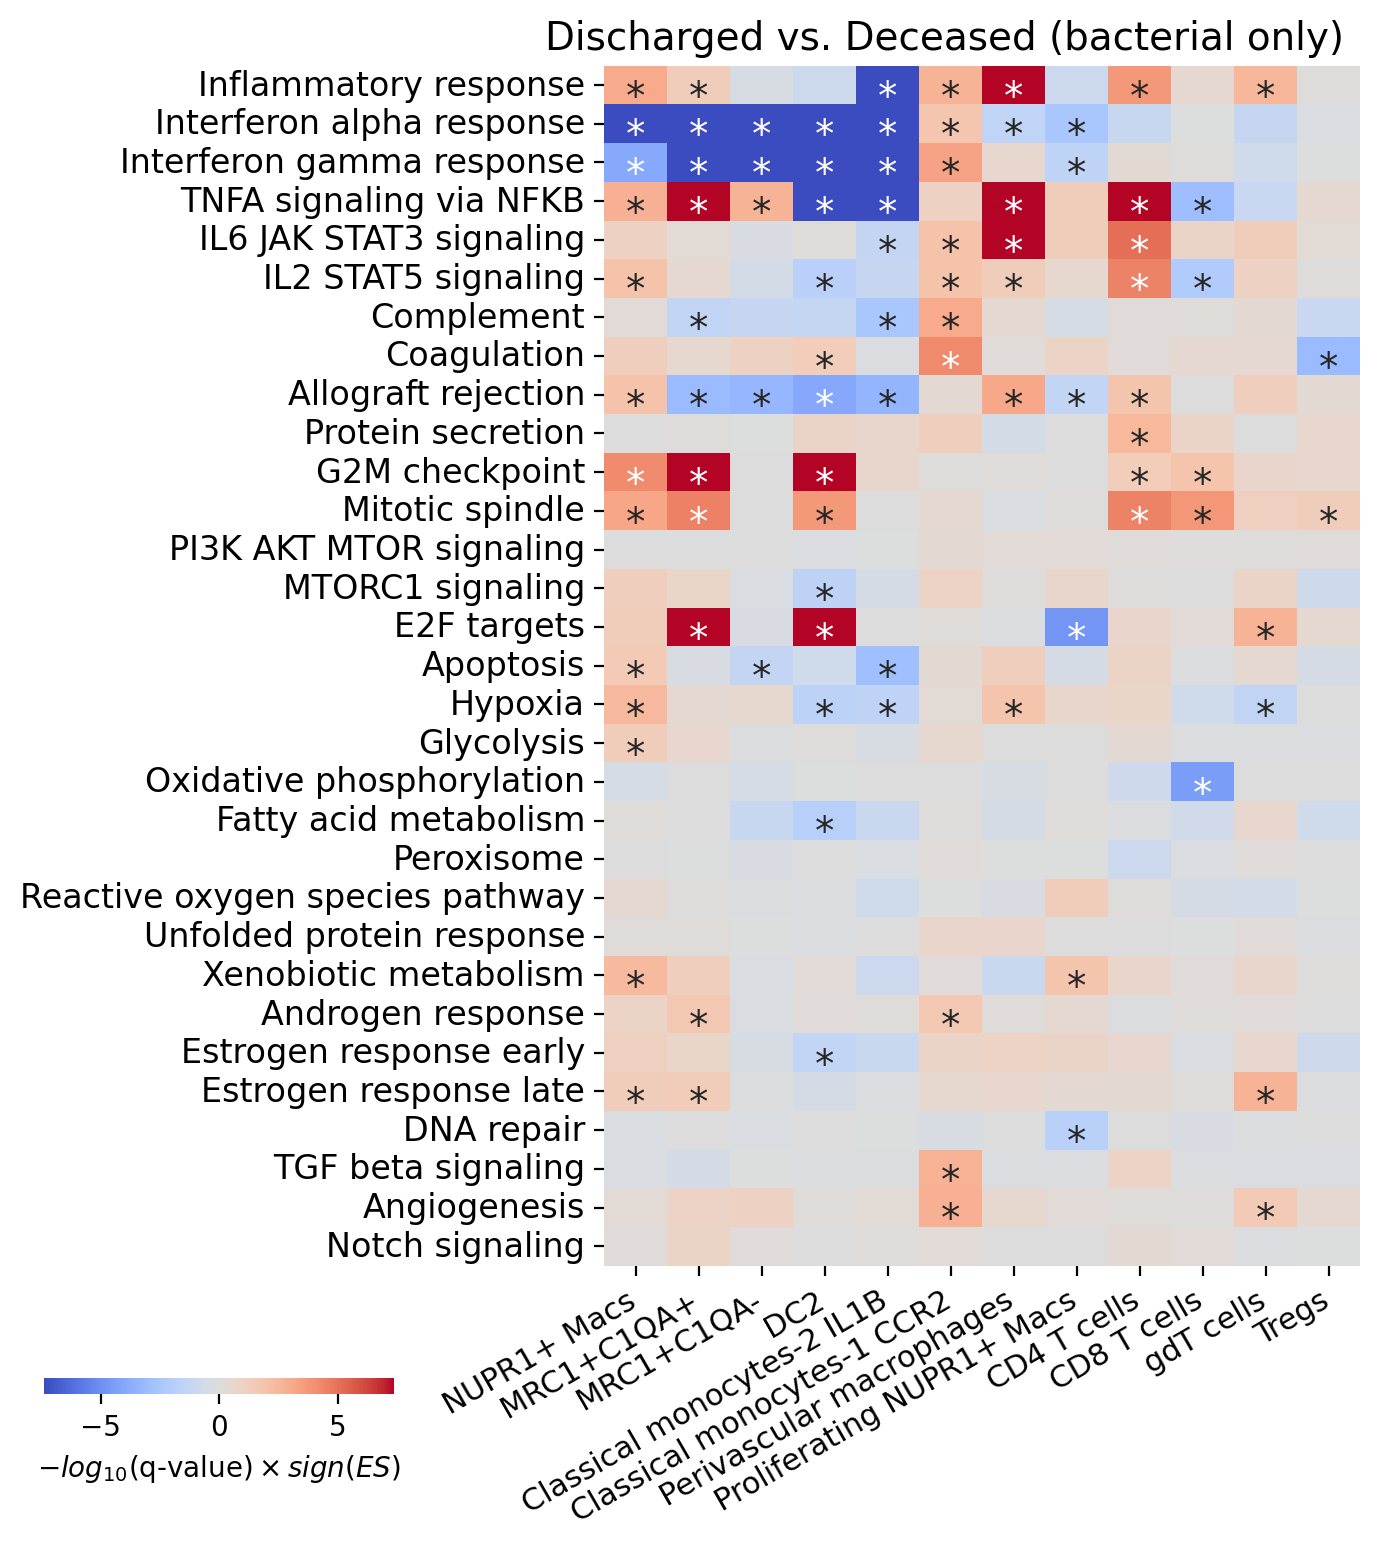

In [ ]:
fig, ax = plt.subplots(constrained_layout=False, figsize=(7, 8))

rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

present_cell_types = pd.Series(MAIN_CELL_TYPE_ORDER)
present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]

stars = np.empty_like(gsea_df_plot, dtype=str)
stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

cax = fig.add_axes((0.05, 0.12, 0.25, 0.01))

cg = sns.heatmap(
    gsea_df_plot,
    cbar_ax=cax,
    xticklabels=gsea_df_plot.columns,
    yticklabels=[pb_utils.process_hallmark_name(x) for x in rownames],
    cmap='coolwarm',
    annot=stars,
    fmt='',
    annot_kws=dict(
        va='center_baseline',
        fontsize=14
    ),
    cbar_kws=dict(
        label='$-log_{10}($q-value$) \\times sign(ES)$',
        orientation='horizontal'
    ),
    ax=ax,
    center=0
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontsize=11,
    rotation=30,
    ha='right'
)
# ax.set_title(ORDER[1 + i], fontsize=12)
trans = mpl.transforms.Affine2D().translate(5, 0)
for t in ax.get_xticklabels():
    t.set_transform(t.get_transform() + trans)
for t in ax.texts:
    if t.get_text() == '*':
        p = t.get_position()
        t.set_position((p[0], p[1] + 0.2))

ax.tick_params(axis='y', labelsize=12, left=True)
ax.tick_params(axis='x', bottom=True)
ax.set_title('Discharged vs. Deceased (bacterial only)', fontsize=14, x=0.45)

fig.subplots_adjust(left=0.45, bottom=0.2, top=0.95, right=0.99)
fig.savefig('00_plots/70b_gsea_alive_vs_dead_bac.pdf')

In [43]:
gsea = result['alive_vs_dead_pathogen_negative']
gsea['p-value'] = gsea['NOM p-value'].copy()
idx = gsea['p-value'].eq(0)
min_p_val = gsea['p-value'][~idx].min()
gsea.loc[idx, 'p-value'] = min_p_val * 0.01

print(f'P-values exactly 0: {idx.sum()} in alive_vs_dead')

gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
gsea['-log10(padj)'] = -np.log10(gsea.padj)
gsea['-log10(padj)'] *= np.sign(gsea.NES)
gsea_df = gsea.pivot_table(
    index='cell_type',
    columns='Term',
    values='-log10(padj)'
)
gsea_df = gsea_df.loc[:, GSEA_LIST]
gsea_df.index = gsea_df.index.str.replace('_', ' ')

gsea_df_plot = gsea_df.fillna(0).T

P-values exactly 0: 28 in alive_vs_dead


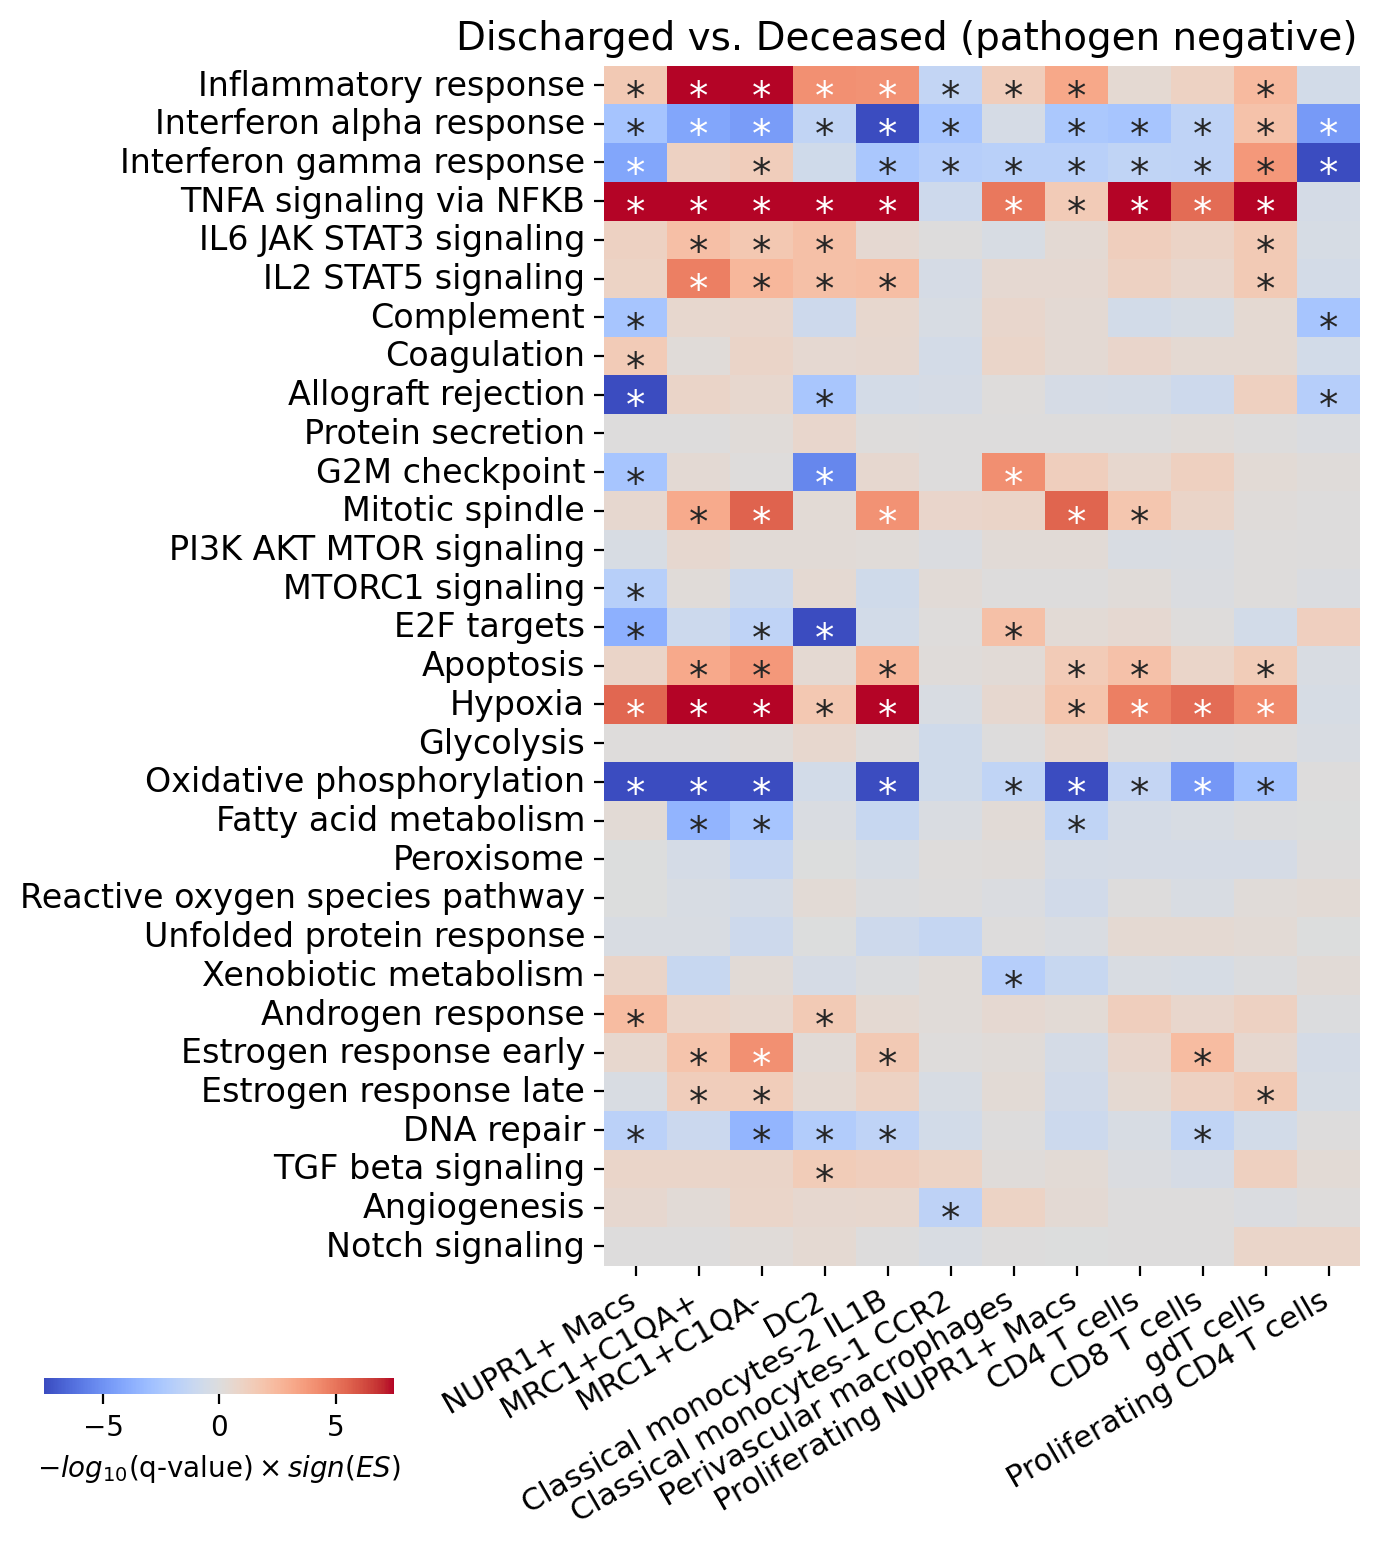

In [ ]:
fig, ax = plt.subplots(constrained_layout=False, figsize=(7, 8))

rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

present_cell_types = pd.Series(MAIN_CELL_TYPE_ORDER)
present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]

stars = np.empty_like(gsea_df_plot, dtype=str)
stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

cax = fig.add_axes((0.05, 0.12, 0.25, 0.01))

cg = sns.heatmap(
    gsea_df_plot,
    cbar_ax=cax,
    xticklabels=gsea_df_plot.columns,
    yticklabels=[pb_utils.process_hallmark_name(x) for x in rownames],
    cmap='coolwarm',
    annot=stars,
    fmt='',
    annot_kws=dict(
        va='center_baseline',
        fontsize=14
    ),
    cbar_kws=dict(
        label='$-log_{10}($q-value$) \\times sign(ES)$',
        orientation='horizontal'
    ),
    ax=ax,
    center=0
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontsize=11,
    rotation=30,
    ha='right'
)
# ax.set_title(ORDER[1 + i], fontsize=12)
trans = mpl.transforms.Affine2D().translate(5, 0)
for t in ax.get_xticklabels():
    t.set_transform(t.get_transform() + trans)
for t in ax.texts:
    if t.get_text() == '*':
        p = t.get_position()
        t.set_position((p[0], p[1] + 0.2))

ax.tick_params(axis='y', labelsize=12, left=True)
ax.tick_params(axis='x', bottom=True)
ax.set_title('Discharged vs. Deceased (pathogen negative)', fontsize=14, x=0.4)

fig.subplots_adjust(left=0.45, bottom=0.2, top=0.95, right=0.99)
fig.savefig('00_plots/70b_gsea_alive_vs_dead_path_neg.pdf')

# 7. GSEA serial baseline

In [ ]:
data = joblib.load('40c_deg_data.joblib')

In [ ]:
SERIAL_BASE = pathlib.Path('../data/05_pseudobulk/40c_degs/')

In [50]:
result = {}
for _, task in data.items():
    gseas = []
    for k, ct_info in task.info.items():
        comp = ct_info.comparisons[0]
        gsea_path = SERIAL_BASE / task.task_info.pathname / k / 'gsea.csv'
        if not gsea_path.exists():
            print(f'No GSEA for {k} in {task.task_info.pathname}')
            continue
        gsea = pd.read_csv(gsea_path, index_col=0)
        gsea['cell_type'] = k
        gseas.append(gsea)
    result[task.task_info.pathname] = pd.concat(gseas)

In [ ]:
gsea = result['baseline']
gsea['p-value'] = gsea['NOM p-value'].copy()
idx = gsea['p-value'].eq(0)
min_p_val = gsea['p-value'][~idx].min()
gsea.loc[idx, 'p-value'] = min_p_val * 0.01

print(f'P-values exactly 0: {idx.sum()} in alive_vs_dead')

gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
gsea['-log10(padj)'] = -np.log10(gsea.padj)
gsea['-log10(padj)'] *= np.sign(gsea.NES)
gsea_df = gsea.pivot_table(
    index='cell_type',
    columns='Term',
    values='-log10(padj)'
)
gsea_df = gsea_df.loc[:, GSEA_LIST]
gsea_df.index = gsea_df.index.str.replace('_', ' ')

gsea_df_plot = gsea_df.fillna(0).T

P-values exactly 0: 30 in alive_vs_dead


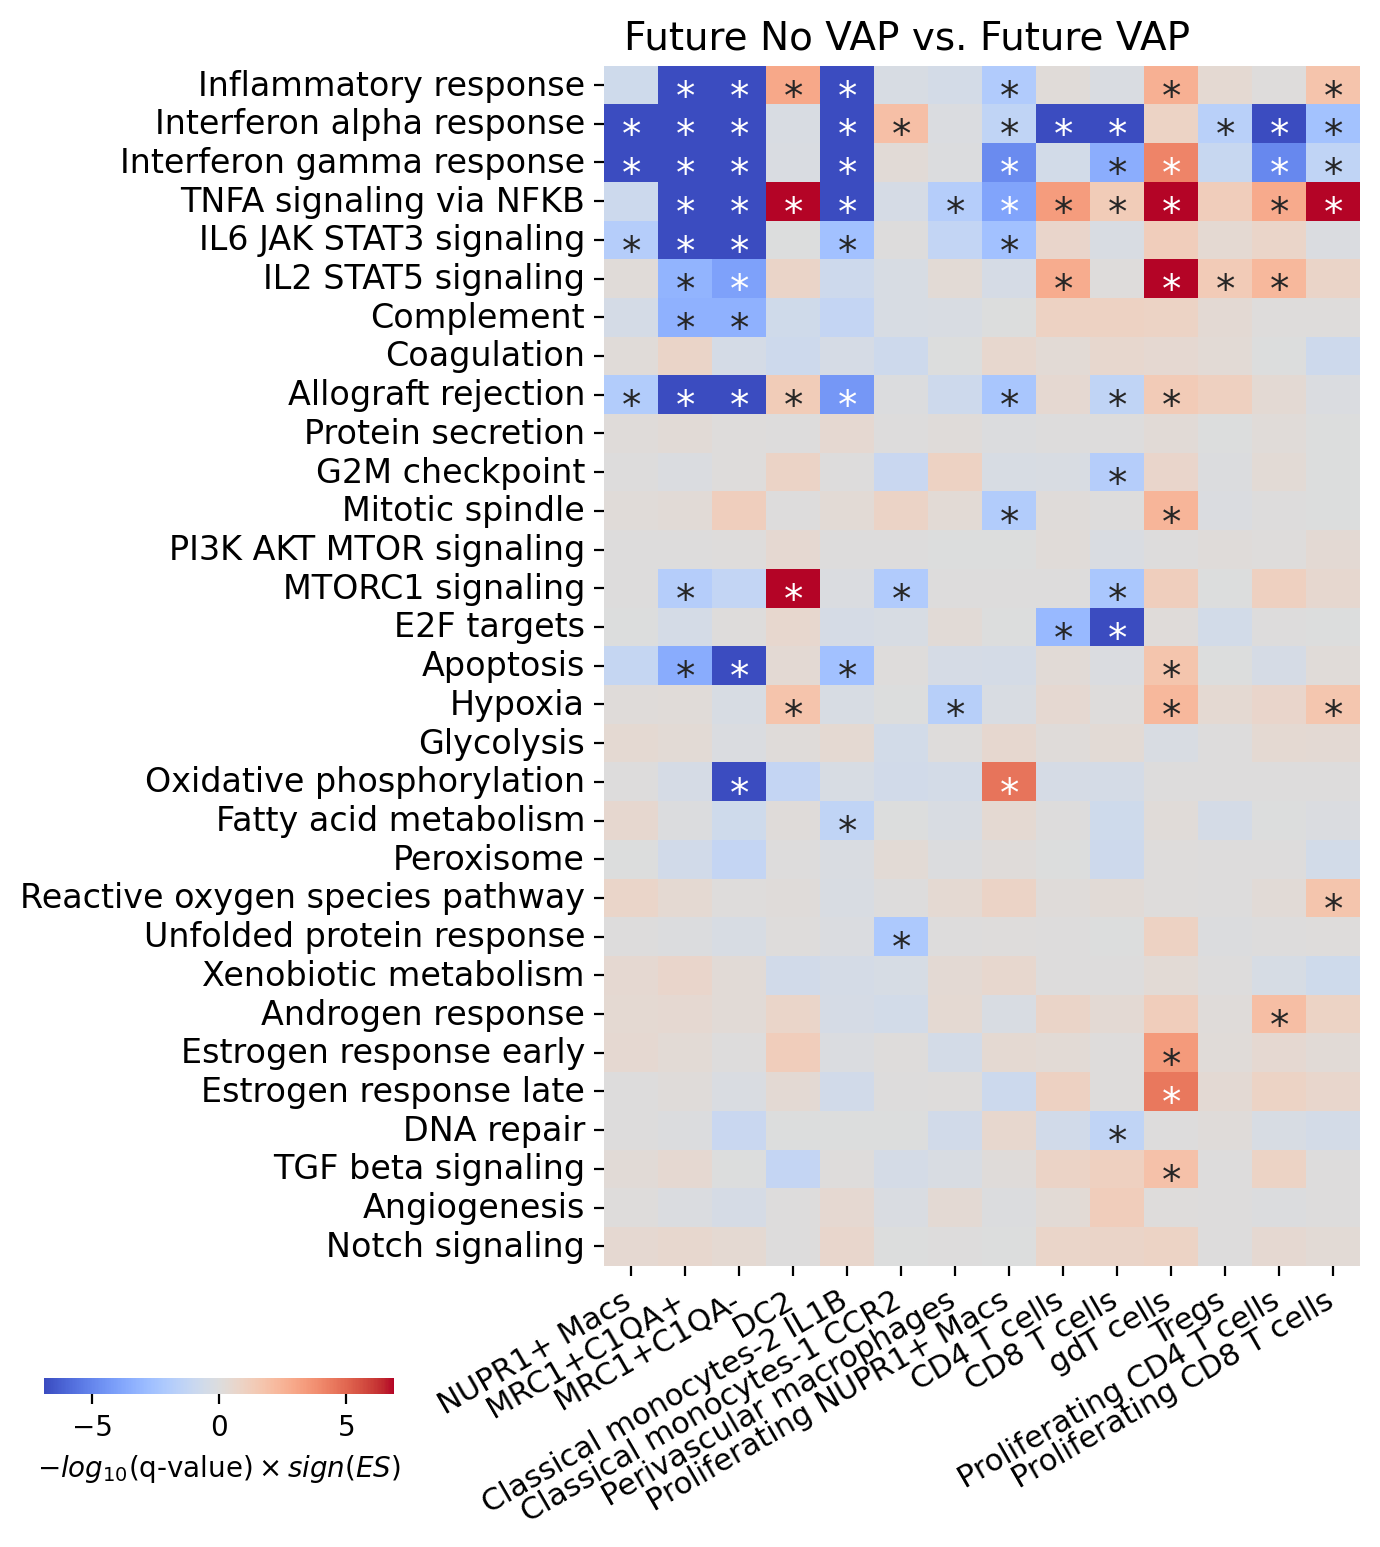

In [ ]:
fig, ax = plt.subplots(constrained_layout=False, figsize=(7, 8))

rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

present_cell_types = pd.Series(MAIN_CELL_TYPE_ORDER)
present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]

stars = np.empty_like(gsea_df_plot, dtype=str)
stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

cax = fig.add_axes((0.05, 0.12, 0.25, 0.01))

cg = sns.heatmap(
    gsea_df_plot,
    cbar_ax=cax,
    xticklabels=gsea_df_plot.columns,
    yticklabels=[pb_utils.process_hallmark_name(x) for x in rownames],
    cmap='coolwarm',
    annot=stars,
    fmt='',
    annot_kws=dict(
        va='center_baseline',
        fontsize=14
    ),
    cbar_kws=dict(
        label='$-log_{10}($q-value$) \\times sign(ES)$',
        orientation='horizontal'
    ),
    ax=ax,
    center=0
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontsize=11,
    rotation=30,
    ha='right'
)
# ax.set_title(ORDER[1 + i], fontsize=12)
trans = mpl.transforms.Affine2D().translate(5, 0)
for t in ax.get_xticklabels():
    t.set_transform(t.get_transform() + trans)
for t in ax.texts:
    if t.get_text() == '*':
        p = t.get_position()
        t.set_position((p[0], p[1] + 0.2))

ax.tick_params(axis='y', labelsize=12, left=True)
ax.tick_params(axis='x', bottom=True)
ax.set_title('Future No VAP vs. Future VAP', fontsize=14, x=0.4)

fig.subplots_adjust(left=0.45, bottom=0.2, top=0.95, right=0.99)
fig.savefig('00_plots/70b_gsea_serial_baseline.pdf')